# Intrinsic Dimensionality Convergence

Tests the prediction from the Platonic Representation Hypothesis: if models converge to the same statistical structure, their **intrinsic dimensionality** should converge across architectures and scales.

Self-contained, runs entirely on CPU with small models.

In [1]:
import sys
sys.path.insert(0, "..")

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import timm
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform
from torchvision.models.feature_extraction import create_feature_extractor

from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset

from metrics import remove_outliers

device = "cpu"
torch.set_grad_enabled(False)
print(f"Device: {device}")

/Users/ayushjain/Development/Research/platonic-rep/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Please install the pymp library using `pip install pymp` to speed up non-batched metrics
Device: cpu


## Dataset

Load a small slice of the WIT dataset (64 samples) — enough for dimensionality estimation while keeping CPU runtime fast.

In [2]:
NUM_SAMPLES = 64

dataset = load_dataset("minhuh/prh", revision="wit_1024", split=f"train[:{NUM_SAMPLES}]")
print(f"Loaded {len(dataset)} samples")
print(f"Keys: {dataset.column_names}")
print(f"Example text: {str(dataset[0]['text'][0])[:100]}...")

Generating train split: 100%|██████████| 1024/1024 [00:01<00:00, 903.91 examples/s] 


Loaded 64 samples
Keys: ['image', 'text', 'origin']
Example text: Figure 2 of Paper. Pseudorhabdosynochus sulamericanus from Hyporthodus haifensis. (A) composite, ven...


## Intrinsic Dimensionality Estimators

In [3]:
def participation_ratio(feats):
    """PR = (sum(lambda))^2 / sum(lambda^2) where lambda are eigenvalues of the covariance matrix.
    
    Ranges from 1 (all variance in one direction) to D (isotropic).
    """
    cov = torch.cov(feats.T)
    eigenvalues = torch.linalg.eigvalsh(cov)
    eigenvalues = eigenvalues.clamp(min=0)
    return (eigenvalues.sum() ** 2) / (eigenvalues ** 2).sum()


def levina_bickel(feats, k=5):
    """MLE intrinsic dimensionality estimator from k-NN distances.
    
    Reference: Levina & Bickel (2004), "Maximum Likelihood Estimation of
    Intrinsic Dimension."
    """
    dists = torch.cdist(feats, feats)
    dists, _ = dists.sort(dim=1)
    # skip self-distance at index 0, use neighbors 1..k+1
    nn_dists = dists[:, 1:k+1].clamp(min=1e-10)
    log_ratios = torch.log(nn_dists[:, -1:] / nn_dists[:, :-1])
    dim_estimates = (k - 1) / log_ratios.sum(dim=1)
    return dim_estimates.mean()


# Sanity check: random Gaussian data in D dimensions should have PR ~ D
for D in [10, 50, 100]:
    rand_feats = torch.randn(256, D)
    pr = participation_ratio(rand_feats).item()
    lb = levina_bickel(rand_feats, k=5).item()
    print(f"D={D:3d} -> PR={pr:.1f}, Levina-Bickel={lb:.1f}")

D= 10 -> PR=9.4, Levina-Bickel=11.7
D= 50 -> PR=42.0, Levina-Bickel=34.7
D=100 -> PR=72.0, Levina-Bickel=50.9


## Vision Models — Extract Features

Use timm ViT models of increasing size (all pretrained on ImageNet-21k).

In [4]:
VISION_MODELS = [
    "vit_tiny_patch16_224.augreg_in21k",
    "vit_small_patch16_224.augreg_in21k",
    "vit_base_patch16_224.augreg_in21k",
]

vision_results = {}

for model_name in VISION_MODELS:
    print(f"\n--- {model_name} ---")
    model = timm.create_model(model_name, pretrained=True).eval()
    num_params = sum(p.numel() for p in model.parameters())
    print(f"Parameters: {num_params/1e6:.1f}M")

    # Build transform from model config
    transform = create_transform(
        **resolve_data_config(model.pretrained_cfg, model=model)
    )

    # Set up feature extraction at each transformer block
    num_blocks = len(model.blocks)
    return_nodes = [f"blocks.{i}.add_1" for i in range(num_blocks)]
    extractor = create_feature_extractor(model, return_nodes=return_nodes)

    # Extract features in batches
    batch_size = 16
    all_feats = []  # will be list of (batch, num_layers, feat_dim)

    for i in tqdm(range(0, NUM_SAMPLES, batch_size), desc="Extracting"):
        batch_end = min(i + batch_size, NUM_SAMPLES)
        ims = torch.stack([transform(dataset[j]["image"]) for j in range(i, batch_end)])
        output = extractor(ims)
        # CLS token (index 0) from each layer
        feats = torch.stack([v[:, 0, :] for v in output.values()]).permute(1, 0, 2)
        all_feats.append(feats)

    all_feats = torch.cat(all_feats, dim=0)  # (N, num_layers, feat_dim)
    print(f"Feature shape: {all_feats.shape}")

    vision_results[model_name] = {
        "feats": all_feats,
        "num_params": num_params,
        "modality": "vision",
    }
    del model, extractor

print("\nDone extracting vision features.")


--- vit_tiny_patch16_224.augreg_in21k ---
Parameters: 9.7M


Extracting: 100%|██████████| 4/4 [00:02<00:00,  1.45it/s]


Feature shape: torch.Size([64, 12, 192])

--- vit_small_patch16_224.augreg_in21k ---
Parameters: 30.1M


Extracting: 100%|██████████| 4/4 [00:03<00:00,  1.17it/s]


Feature shape: torch.Size([64, 12, 384])

--- vit_base_patch16_224.augreg_in21k ---
Parameters: 102.6M


Extracting: 100%|██████████| 4/4 [00:05<00:00,  1.48s/it]

Feature shape: torch.Size([64, 12, 768])

Done extracting vision features.


## Language Models — Extract Features

Use a small Bloom model that fits comfortably on CPU.

In [5]:
LANGUAGE_MODELS = [
    "bigscience/bloomz-560m",
]

texts = [str(x["text"][0]) for x in dataset]

language_results = {}

for model_name in LANGUAGE_MODELS:
    print(f"\n--- {model_name} ---")
    model = AutoModelForCausalLM.from_pretrained(
        model_name, torch_dtype=torch.float32, output_hidden_states=True,
    ).eval()
    num_params = sum(p.numel() for p in model.parameters())
    print(f"Parameters: {num_params/1e6:.1f}M")

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"

    tokens = tokenizer(texts, padding="longest", return_tensors="pt", truncation=True, max_length=128)

    batch_size = 8
    all_feats = []

    for i in tqdm(range(0, NUM_SAMPLES, batch_size), desc="Extracting"):
        batch_end = min(i + batch_size, NUM_SAMPLES)
        batch = {k: v[i:batch_end] for k, v in tokens.items()}
        output = model(**batch)

        # Average-pool over tokens (respecting attention mask)
        hidden_states = torch.stack(output.hidden_states).permute(1, 0, 2, 3)  # (B, L, T, D)
        mask = batch["attention_mask"].unsqueeze(1).unsqueeze(-1)  # (B, 1, T, 1)
        feats = (hidden_states * mask).sum(dim=2) / mask.sum(dim=2)  # (B, L, D)
        all_feats.append(feats)

    all_feats = torch.cat(all_feats, dim=0)
    print(f"Feature shape: {all_feats.shape}")

    language_results[model_name] = {
        "feats": all_feats,
        "num_params": num_params,
        "modality": "language",
    }
    del model, tokenizer

print("\nDone extracting language features.")


--- bigscience/bloomz-560m ---


`torch_dtype` is deprecated! Use `dtype` instead!
The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Loading weights: 100%|██████████| 293/293 [00:02<00:00, 126.73it/s]


Parameters: 559.2M


Extracting: 100%|██████████| 8/8 [00:13<00:00,  1.63s/it]

Feature shape: torch.Size([64, 25, 1024])

Done extracting language features.


## Compute Intrinsic Dimensionality

For each model, compute participation ratio and Levina-Bickel at every layer.

In [6]:
all_results = {**vision_results, **language_results}

dim_results = {}  # {model_name: {"pr": [...], "lb": [...], "num_params": int, "modality": str}}

for model_name, data in all_results.items():
    feats = data["feats"]  # (N, num_layers, D)
    num_layers = feats.shape[1]
    pr_per_layer = []
    lb_per_layer = []

    for layer_idx in range(num_layers):
        layer_feats = feats[:, layer_idx, :]  # (N, D)
        # Remove outliers and normalize
        layer_feats = remove_outliers(layer_feats, q=0.95)
        layer_feats = F.normalize(layer_feats, dim=-1)

        pr = participation_ratio(layer_feats).item()
        lb = levina_bickel(layer_feats, k=5).item()
        pr_per_layer.append(pr)
        lb_per_layer.append(lb)

    dim_results[model_name] = {
        "pr": pr_per_layer,
        "lb": lb_per_layer,
        "num_params": data["num_params"],
        "modality": data["modality"],
    }

    short_name = model_name.split("/")[-1]
    print(f"{short_name}: last-layer PR={pr_per_layer[-1]:.1f}, LB={lb_per_layer[-1]:.1f}, "
          f"best-layer PR={max(pr_per_layer):.1f} (layer {np.argmax(pr_per_layer)})")

vit_tiny_patch16_224.augreg_in21k: last-layer PR=36.2, LB=30.3, best-layer PR=36.2 (layer 11)
vit_small_patch16_224.augreg_in21k: last-layer PR=45.4, LB=43.3, best-layer PR=45.4 (layer 11)
vit_base_patch16_224.augreg_in21k: last-layer PR=52.8, LB=59.0, best-layer PR=52.8 (layer 11)
bloomz-560m: last-layer PR=35.7, LB=27.5, best-layer PR=49.0 (layer 1)


## Plot Results

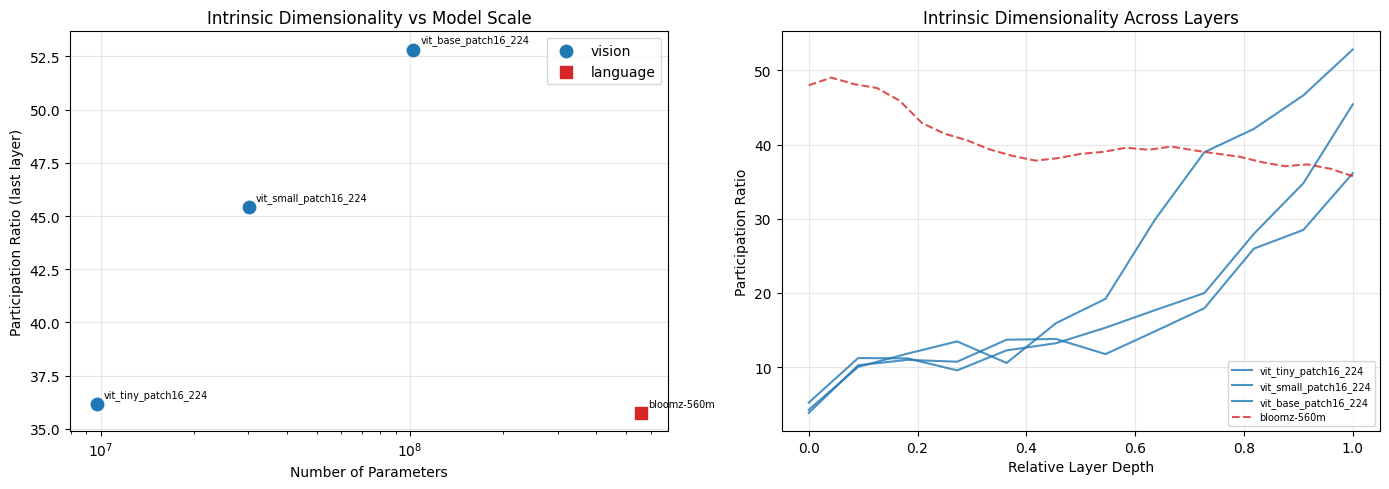

Saved plot to experiments/intrinsic_dimensionality.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Intrinsic dim (last layer) vs model scale ---
ax = axes[0]
markers = {"vision": "o", "language": "s"}
colors = {"vision": "tab:blue", "language": "tab:red"}

for model_name, data in dim_results.items():
    mod = data["modality"]
    short_name = model_name.split("/")[-1].split(".")[0]
    ax.scatter(
        data["num_params"], data["pr"][-1],
        marker=markers[mod], color=colors[mod], s=80, zorder=3,
    )
    ax.annotate(short_name, (data["num_params"], data["pr"][-1]),
                fontsize=7, ha="left", va="bottom", xytext=(5, 3),
                textcoords="offset points")

ax.set_xscale("log")
ax.set_xlabel("Number of Parameters")
ax.set_ylabel("Participation Ratio (last layer)")
ax.set_title("Intrinsic Dimensionality vs Model Scale")
# Legend
for mod in ["vision", "language"]:
    ax.scatter([], [], marker=markers[mod], color=colors[mod], label=mod, s=80)
ax.legend()
ax.grid(True, alpha=0.3)

# --- Plot 2: Intrinsic dim across layers ---
ax = axes[1]
for model_name, data in dim_results.items():
    mod = data["modality"]
    num_layers = len(data["pr"])
    x = np.linspace(0, 1, num_layers)  # normalize layer index to [0, 1]
    short_name = model_name.split("/")[-1].split(".")[0]
    linestyle = "-" if mod == "vision" else "--"
    ax.plot(x, data["pr"], linestyle=linestyle, color=colors[mod], label=short_name, alpha=0.8)

ax.set_xlabel("Relative Layer Depth")
ax.set_ylabel("Participation Ratio")
ax.set_title("Intrinsic Dimensionality Across Layers")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("intrinsic_dimensionality.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved plot to experiments/intrinsic_dimensionality.png")